In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

Shape of the training set is  (2000, 2) .
Shape of the test set is (1000, 2) .
Shape of the target vector is (2000, 1) .


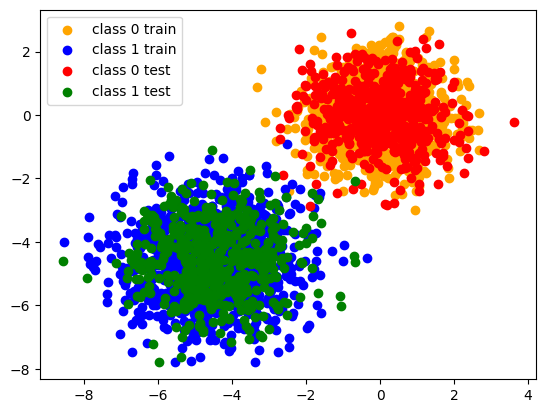

In [ ]:
np.random.seed(10)

# generate two classes of samples X_1 and X_2
X_1 =  np.random.randn(1500,2)
X_2 = 1.2*np.random.randn(1500,2)-4.5

# divide them into:
# training set
X_1_train = X_1[:1000, :]
X_2_train = X_2[:1000, :]

# test set
X_1_test = X_1[1000:, :]
X_2_test = X_2[1000:, :]



# X_train is training set used in algorithm
X_train = np.vstack([X_1_train, X_2_train])

# y is a set of tagrets
# The first 1000 samples are from class 0
y = np.zeros((2000,1))
# The last 1000 samples are from class 1
y[ 1000:, 0] = 1

X_test = np.vstack([X_1_test, X_2_test])
print('Shape of the training set is  (%i, %i) .'% X_train.shape)
print('Shape of the test set is (%i, %i) .'% X_test.shape)
print('Shape of the target vector is (%i, %i) .' % y.shape)


# plot training and test set
plt.scatter(X_1_train[:,0], X_1_train[:, 1], label = 'class 0 train', color = 'Orange')
plt.scatter(X_2_train[:,0], X_2_train[:, 1], label = 'class 1 train', color = 'Blue')

plt.scatter(X_1_test[:,0], X_1_test[:,1],label = 'class 0 test', color = 'r')
plt.scatter(X_2_test[:,0], X_2_test[:,1], label = 'class 1 test', color = 'g')

plt.legend()
plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression

LR = LogisticRegression()
LR.fit(X_train, y.reshape((y.shape[0],))) # it is preferable to use y of this shape
print('Ceoficients of LogisticRegression from sklearn are in (%i,%i) dimensional matrix' %LR.coef_.shape)
w1_skl= LR.coef_[0,0]
w2_skl= LR.coef_[0,1]
b_skl = LR.intercept_


print('w1 = %f'%w1_skl)
print('w2 = %f'%w2_skl)
print('b = %f'%b_skl)

Ceoficients of LogisticRegression from sklearn are in (1,2) dimensional matrix
w1 = -2.351219
w2 = -2.591243
b = -10.139137


<ipython-input-6-c66af979b38c>:13: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print('b = %f'%b_skl)


In [ ]:
# prediction
y_test_sklearn = LR.predict(X_test).reshape(1000,1)

# Confusion matrix:

In [ ]:
cm_sk = metrics.confusion_matrix(y_test, y_test_sklearn)
cm_sk

array([[498,   2],
       [  1, 499]])

## We will generate two datasets and plot them

Element from class 0 with index 300 , feature1= -1.879757 and feature2=-2.862382 is misclassified.
Element from class 0 with index 321 , feature1= -2.613556 and feature2=-1.879211 is misclassified.
Element from class 1 with index 579 , feature1= -0.667955 and feature2=-2.092435 is misclassified.


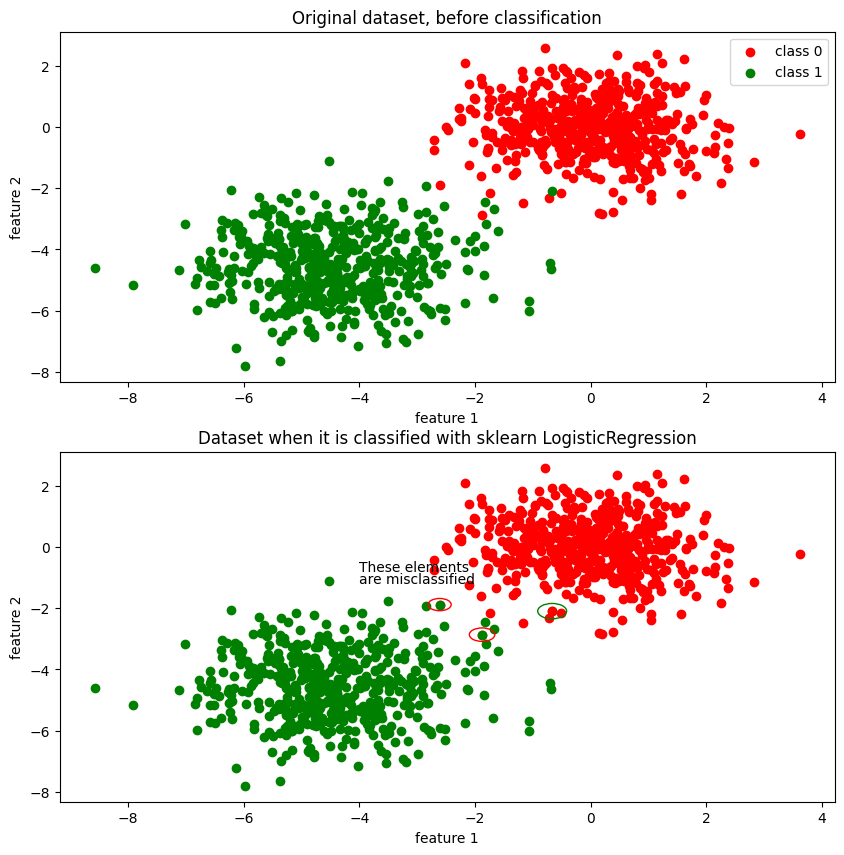

In [ ]:
from matplotlib.patches import Circle

plt.figure(figsize = (10,10))
plt.subplot(2,1,1)
plt.scatter(X_1_test[:,0], X_1_test[:,1], label = 'class 0', color = 'r')
plt.scatter(X_2_test[:,0], X_2_test[:,1], label = 'class 1', color = 'g')
plt.xlabel('feature 1')
plt.ylabel('feature 2')
plt.title('Original dataset, before classification')
plt.legend()


plt.subplot(2,1,2)
for i in range(0,500):
    plt.scatter(X_test[i,0], X_test[i,1],  color = 'r')
    if y_test_sklearn[i] == 1:
        plt.scatter(X_test[i,0], X_test[i,1], color = 'g')
        print('Element from class 0 with index %i , feature1= %f and feature2=%f is misclassified.'%(i, X_test[i,0], X_test[i,1]))
for i in range(500,1000):
    plt.scatter(X_test[i,0], X_test[i,1],  color = 'g')
    if y_test_sklearn[i] == 0:
        plt.scatter(X_test[i,0], X_test[i,1], color = 'r')
        print('Element from class 1 with index %i , feature1= %f and feature2=%f is misclassified.'%(i, X_test[i,0], X_test[i,1]))


plt.xlabel('feature 1')
plt.ylabel('feature 2')
plt.title('Dataset when it is classified with sklearn LogisticRegression')
circle1 = plt.Circle((-1.879757,-2.862382), radius=0.22, color = 'r', fill=False)
circle2 = plt.Circle((-2.613556,-1.879211), radius=0.20, color = 'r', fill=False)
circle3 = plt.Circle((-0.667955,-2.092435), radius=0.25, color = 'g', fill=False)

plt.text(-4,-0.8, 'These elements')
plt.text(-4,-1.2, 'are misclassified')
plt.gca().add_patch(circle1)
plt.gca().add_patch(circle2)
plt.gca().add_patch(circle3)


plt.show()


In [ ]:
# Parameters from Logistic Regression trained from scratch
w1_final = -2.882705
w2_final = -3.150111
b_final = -12.158909

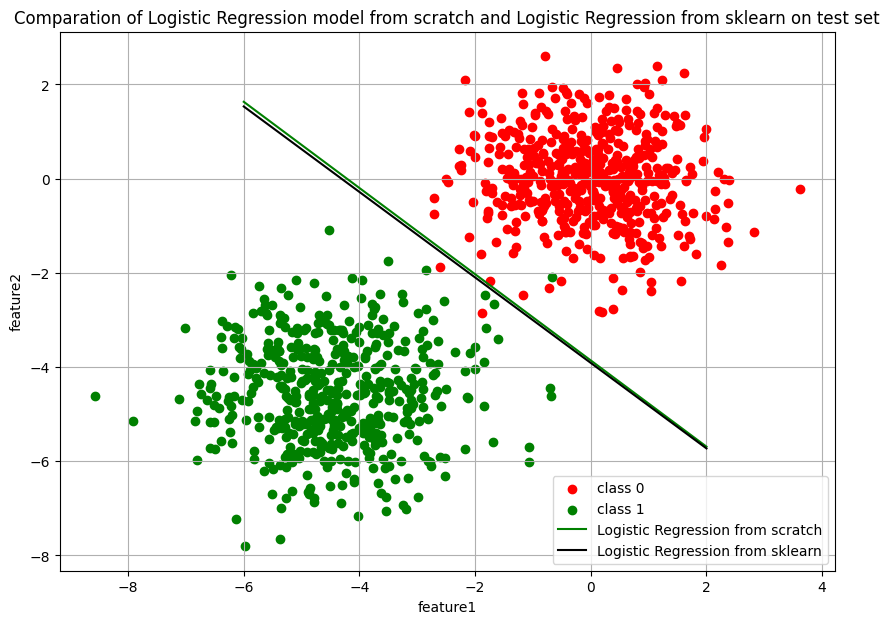

In [ ]:
xx = np.linspace(-6,2 )
yy_lr = -(w1_final/w2_final)*xx - b_final/w2_final
yy_sk = -(w1_skl/w2_skl)*xx - b_skl/w2_skl

plt.figure(figsize =(10,7))
plt.scatter(X_1_test[:,0], X_1_test[:,1], label = 'class 0', color = 'r')
plt.scatter(X_2_test[:,0], X_2_test[:,1], label = 'class 1', color = 'g')
plt.plot(xx, yy_lr, label = 'Logistic Regression from scratch', color = 'g')
plt.plot(xx, yy_sk, label = 'Logistic Regression from sklearn', color = 'k')
plt.xlabel('feature1')
plt.ylabel('feature2')
plt.title('Comparation of Logistic Regression model from scratch and Logistic Regression from sklearn on test set')
plt.legend()
plt.grid()
plt.show()

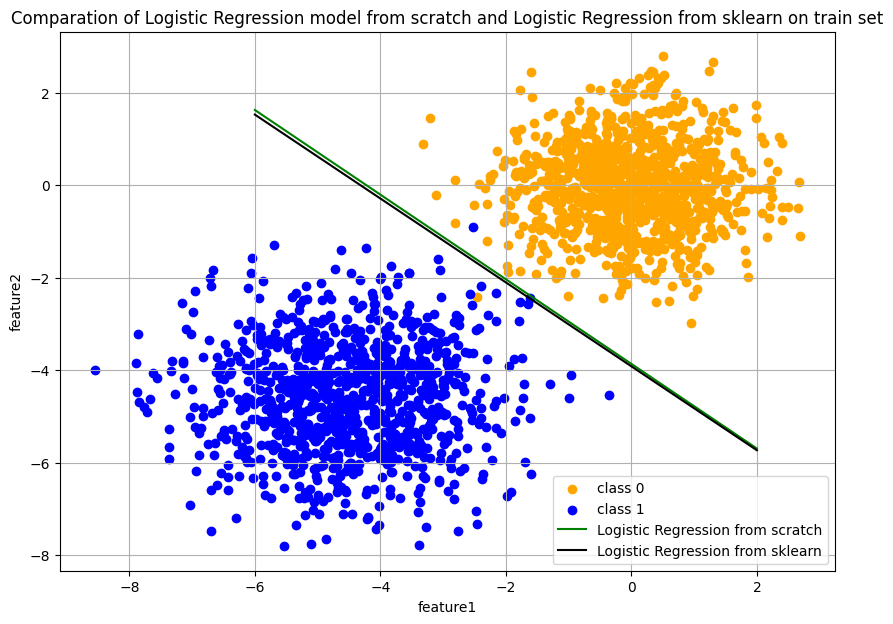

In [ ]:
plt.figure(figsize =(10,7))
plt.scatter(X_1_train[:,0], X_1_train[:,1],  label = 'class 0', color ='Orange')
plt.scatter(X_2_train[:,0], X_2_train[:,1],  label = 'class 1', color = 'Blue')
plt.plot(xx, yy_lr, label = 'Logistic Regression from scratch', color = 'g')
plt.plot(xx, yy_sk, label = 'Logistic Regression from sklearn', color = 'k')
plt.xlabel('feature1')
plt.ylabel('feature2')
plt.title('Comparation of Logistic Regression model from scratch and Logistic Regression from sklearn on train set')
plt.legend()
plt.grid()